<a href="https://colab.research.google.com/github/paulynamagana/AFDB_notebooks/blob/main/afdb_msa_conservation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analysing AlphaFold's Database Multiple Sequence Alignments (MSAs)

## Introduction

Multiple sequence alignments (MSAs) are the primary source of evolutionary signal that AlphaFold 2 uses to predict protein structure. The Evoformer module at the core of AlphaFold 2 learns directly from patterns in the MSA, detecting which positions are invariant across species (conservation) and which positions change together in correlated ways (co-variation), to infer the three-dimensional constraints that determine a protein's fold ([Jumper et al., 2021](https://www.nature.com/articles/s41586-021-03819-2)).

The AlphaFold Database (AFDB) provides precomputed MSAs for every entry in its proteome-scale predictions, built by searching UniRef90 and MGnify with HHblits and Jackhmmer. These MSAs are available as .a3m files and represent exactly the evolutionary input that was fed to the model during prediction. Analysing them directly allows us to interrogate the evidence base behind every predicted structure and confidence score.

This notebook demonstrates how to programmatically access and analyse AFDB MSAs, with sequence conservation as the central analysis. I designed it as both a conceptual reference and a practical workflow.

## MSA Depth vs. Diversity: Why quantity is not enough

A natural assumption is that a bigger MSA is always better. This is not generally true, and understanding why, matters for interpreting both AlphaFold predictions and the analyses in this notebook.

- Depth refers to the raw number of sequences in the alignment.
- Diversity refers to how evolutionarily distinct those sequences are from one another.

A concrete illustration:
- an MSA with 5,000 sequences drawn entirely from closely related mammalian variants may be almost entirely redundant, every sequence is >98% identical to the query, contributing little independent information about which residues can tolerate change.
- In contrast, 200 sequences spanning bacteria, archaea, fungi, and vertebrates, with pairwise identities of 30–60%, encode far richer co-evolutionary signal. AlphaFold's performance is sensitive to this distinction.

A common approach to quantify the alignment depth of an MSA is by counting the normalised number of effective sequences (Neff), rather than simply reporting raw sequence count. Neff downweights near-duplicate sequences to give an estimate of the true evolutionary information content of the alignment, and is a widely used metric in structure prediction pipelines.

If you would like a clear and practical discussion of Neff (number of effective sequences) and why it matters, I recommend reading:

>   [Zhang et al., DeepMSA: constructing deep multiple sequence alignment to improve contact prediction and fold-recognition for distant-homology proteins. Bioinformatics (2020).](https://doi.org/10.1093/bioinformatics/btz863)

## What this notebook covers

This notebook walks through the following analyses in order:

1. Fetching AFDB data: querying the AlphaFold API to retrieve the predicted structure, pLDDT confidence scores, PAE matrix, and MSA for a protein of interest.
2. MSA sanity checking: visualising the alignment as an identity map relative to the query sequence, to inspect coverage and gap patterns before running any metrics.
3. MSA diversity (Neff): computing the effective number of sequences to assess how much independent evolutionary variation the alignment contains.
4. Per-residue conservation (Shannon entropy and KL divergence): calculating position-wise conservation scores, identifying the most conserved and compositionally unusual positions, and smoothing profiles for structural interpretation.


- **Note:** Conservation is necessary but not sufficient for functional annotation. A conserved residue could be critical for folding stability rather than catalysis or binding. I recommend cross-referencing with structural context, sequence/structure annotations (e.g., from UniProt or PDB), and experimental data.


In [ ]:
#@title # Import and install libraries
!pip install BioPython
!pip install py3Dmol

import numpy as np
import matplotlib.pyplot as plt
import requests
import re
from io import StringIO
from collections import Counter
from Bio import AlignIO
from Bio.PDB import PDBParser, PDBIO
import py3Dmol
import json
import seaborn as sns
import pandas as pd
from scipy.spatial.distance import pdist, squareform
from scipy.ndimage import uniform_filter1d
from matplotlib.patches import Patch
from IPython.display import display, HTML

sns.set_style('whitegrid')

print("----All packages imported successfully---")


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
----All packages imported successfully---


## <font color='#077187' size=16>**Fetch the data**</font>

In [ ]:
uniprot_id = "Q92794" #@param {type:"string"}

url_pdb_prediction = f"https://alphafold.ebi.ac.uk/api/prediction/{uniprot_id.strip()}"

try:
    response = requests.get(url_pdb_prediction, timeout=20)
    if response.status_code == 200:
        result = response.json()
        print(json.dumps(result, indent=2))
    else:
        print(f"Error getting prediction for {uniprot_id}")
except requests.RequestException as e:
    print(f"Error during request: {e}")

[
  {
    "toolUsed": "AlphaFold Monomer v2.0 pipeline",
    "providerId": "GDM",
    "entityType": "protein",
    "isUniProt": true,
    "modelEntityId": "AF-Q92794-F1",
    "modelCreatedDate": "2025-08-01T00:00:00Z",
    "sequenceVersionDate": "2008-11-25T00:00:00Z",
    "globalMetricValue": 48.66,
    "fractionPlddtVeryLow": 0.699,
    "fractionPlddtLow": 0.03,
    "fractionPlddtConfident": 0.102,
    "fractionPlddtVeryHigh": 0.169,
    "latestVersion": 6,
    "allVersions": [
      1,
      2,
      3,
      4,
      5,
      6
    ],
    "sequence": "MVKLANPLYTEWILEAIKKVKKQKQRPSEERICNAVSSSHGLDRKTVLEQLELSVKDGTILKVSNKGLNSYKDPDNPGRIALPKPRNHGKLDNKQNVDWNKLIKRAVEGLAESGGSTLKSIERFLKGQKDVSALFGGSAASGFHQQLRLAIKRAIGHGRLLKDGPLYRLNTKATNVDGKESCESLSCLPPVSLLPHEKDKPVAEPIPICSFCLGTKEQNREKKPEELISCADCGNSGHPSCLKFSPELTVRVKALRWQCIECKTCSSCRDQGKNADNMLFCDSCDRGFHMECCDPPLTRMPKGMWICQICRPRKKGRKLLQKKAAQIKRRYTNPIGRPKNRLKKQNTVSKGPFSKVRTGPGRGRKRKITLSSQSASSSSEEGYLERIDGLDFCRDSNVSLKFNKKTKGLIDGLTKFFTPSPDGRKARGEVVDYSEQYR

In [ ]:
#@markdown This code block will print a table of all available entries for that UniProt ID, which can include isoforms.

print(f"All entries for the UniProt ID {uniprot_id}:")

rows= []

for item in result:
    modelID = item.get("modelEntityId")
    description = item.get("uniprotDescription")
    latestVersion = item.get("latestVersion")
    average_plddt = item.get("globalMetricValue")
    fractionPlddtVeryLow = item.get("fractionPlddtVeryLow")
    fractionPlddtLow = item.get("fractionPlddtLow")
    fractionPlddtConfident = item.get("fractionPlddtConfident")
    fractionPlddtVeryHigh = item.get("fractionPlddtVeryHigh")

    rows.append({
        "model_ID": modelID,
        "description":description,
        "average_plddt": average_plddt,
        "latest_version": latestVersion,
        "fractionPlddtVeryLow": "{:.1f}%".format(fractionPlddtVeryLow * 100),
        "fractionPlddtLow": "{:.1f}%".format(fractionPlddtLow* 100),
        "fractionPlddtConfident": "{:.1f}%".format(fractionPlddtConfident* 100),
        "fractionPlddtVeryHigh": "{:.1f}%".format(fractionPlddtVeryHigh* 100)
    })

df = pd.DataFrame(rows)
df

All entries for the UniProt ID Q92794:


,model_ID,description,average_plddt,latest_version,fractionPlddtVeryLow,fractionPlddtLow,fractionPlddtConfident,fractionPlddtVeryHigh
0,AF-Q92794-F1,Histone acetyltransferase KAT6A,48.66,6,69.9%,3.0%,10.2%,16.9%


In [ ]:
#@markdown Now, choose one model ID to analyse the MSA.
#@markdown This code block will first visualise the structure and the PAE plot
model = "AF-Q92794-F1"#@param {type:"string"}
plddt_url = msa_url = pdbUrl = paeDocUrl = None

for entry in result:
    if entry["modelEntityId"] == model:
        plddt_url = entry["plddtDocUrl"]
        msa_url = entry["msaUrl"]
        pdbUrl = entry["pdbUrl"]
        paeDocUrl = entry["paeDocUrl"]
        break
if not model:
    print(f"Model {model} not found in results.")
if msa_url is None:
    raise ValueError(f"Model {model} not found for UniProt ID {uniprot_id}.")

if plddt_url and msa_url:
    plddt_response = requests.get(plddt_url)
    plddt_data = plddt_response.json()

    plddt_scores = plddt_data['confidenceScore']
    residue_number = plddt_data['residueNumber']
    print(f"Successfully fetched pLDDT for {len(plddt_scores)} residues.")

    msa_response = requests.get(msa_url)
    msa_content = msa_response.text # Get the raw text of the .a3m file
    print("Successfully fetched MSA content.")

else:
    print(f"Error: Could not find URLs for model {model}")

def parse_a3m_content(msa_content):
    """Parses the A3M content into a list of uppercase sequences."""
    sanitised_content = re.sub(r'[a-z]', '', msa_content)

    alignment = AlignIO.read(StringIO(sanitised_content), "fasta")

    #convert to a simple list of strings
    msa_array = np.array([list(str(rec.seq)) for rec in alignment])

    return msa_array

print("Parsing A3M content...")
msa_array = parse_a3m_content(msa_content)
query_seq = msa_array[0]
print(f"Parsing complete. Found {len(msa_array)} sequences.")

Successfully fetched pLDDT for 2004 residues.
Successfully fetched MSA content.
Parsing A3M content...
Parsing complete. Found 10151 sequences.


A3M parsing in this notebook: lowercase insertion letters are removed, uppercase aligned residues are kept, and $-$ gaps are retained. This converts the A3M into a query-aligned matrix so each column maps to a query residue position before computing entropy/KL and coverage/support metrics.

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

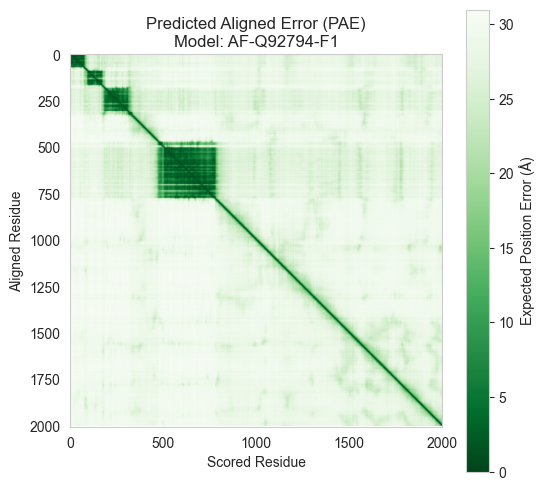

In [ ]:
#@markdown Run this cell to see the structure coloured by pLDDT and the PAE plot

def plot_pae(pae_url):
    response = requests.get(pae_url)
    data = response.json()

    if isinstance(data, list) and len(data) > 0:
        pae_matrix = data[0]['predicted_aligned_error']
    else:
        print("Invalid PAE data format.")
        return

    # Plotting
    plt.figure(figsize=(6, 6))
    plt.imshow(pae_matrix, cmap='Greens_r', vmin=0, vmax=31)

    cb = plt.colorbar()
    cb.set_label('Expected Position Error (Å)')
    plt.title(f'Predicted Aligned Error (PAE)\nModel: {model}')
    plt.xlabel('Scored Residue')
    plt.ylabel('Aligned Residue')
    plt.grid(False)
    plt.show()

def show_structure_and_image(pdb_url, paeUrl, color="plDDT"):
    pdb_data = requests.get(pdb_url).text
    # Create a 3Dmol.js view
    view = py3Dmol.view(js='https://3dmol.org/build/3Dmol.js')
    # Add the PDB data to the view
    view.addModel(pdb_data, 'pdb')

    if color == "plDDT":
        view.setStyle({'cartoon': {'colorscheme': {'prop': 'b', 'gradient': 'roygb', 'min': 50, 'max': 90}}})
    elif color == "rainbow":
        view.setStyle({'cartoon': {'color': 'spectrum'}})

    # Zoom to the structure
    view.zoomTo()
    display(view) # Display
    plot_pae(paeUrl) # Display

show_structure_and_image(pdbUrl, paeDocUrl, "plDDT")


# <font color='#077187' size=16>**Visual sanity check: MSA identity map**</font>

Before computing any quantitative metrics, it is good practice to visually inspect
the alignment. This plot encodes a single binary question at each position for each
sequence:

*"Does this residue match the query (the first sequence in the alignment)?"*

- **Dark**: residue matches the query at this column  
- **Light**: different residue or a gap

### What to look for

- **Coverage and gap patterns.** Large light horizontal bands indicate sequences with poor coverage of the query region, often reflecting domain insertions or deletions in those homologs, or alignment to only one domain of a multi-domain protein. Extensive gaps concentrated at the N- or C-terminus are common and generally expected.

- **Redundancy clusters.** If a dense block of nearly identical dark rows appears near the top of the map, the MSA likely contains many closely related sequences (e.g., from the same genus or species group). This is not a problem per se, but it means raw sequence count overstates the true evolutionary diversity, exactly what the Neff calculation in the next section corrects for.

- **Incoherent alignments.** If the map looks entirely random with no coherent vertical structure, the MSA may contain weakly homologous sequences, sequences from mismatched protein families, or the alignment may simply be too shallow to carry useful signal.

This plot is a quality diagnostic. Use it to confirm the alignment looks structurally reasonable, then proceed to Neff and per-residue conservation for quantitative inference.

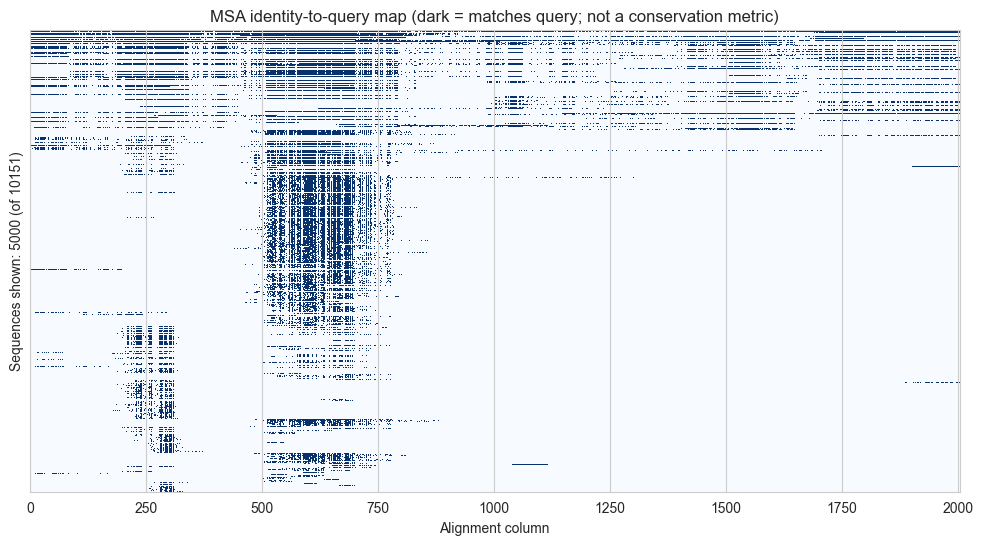

In [ ]:
#@markdown This code block will show a binary identity-to-query map for quick sanity checking of the MSA.

#@markdown - Dark = matches the query residue at that column (including '-' if present).
#@markdown - Light = mismatch.

#@markdown  Note: This is NOT a conservation plot; it's identity relative to the query.

#@markdown  If you prefer, you can change the maximum number of sequences to use here:
max_seqs = 4000 #@param {type:"number"}

def plot_msa_identity_map(msa_num, max_seqs=5000):
    """
    Binary identity-to-query map for quick sanity checking.
    Dark = matches the query residue at that column (including '-' if present).
    Light = mismatch.
    Note: This is NOT a conservation plot; it's identity relative to the query.
    """
    n_seqs = msa_num.shape[0]

    # Subsample uniformly if too large for matplotlib
    if n_seqs > max_seqs:
        indices = np.linspace(0, n_seqs - 1, max_seqs, dtype=int)
        display_msa = msa_num[indices]
        shown = max_seqs
    else:
        display_msa = msa_num
        shown = n_seqs

    query_seq = display_msa[0]
    matches = (display_msa == query_seq)

    plt.figure(figsize=(12, 6))
    plt.imshow(matches, aspect='auto', cmap='Blues', interpolation='nearest')
    plt.title("MSA identity-to-query map (dark = matches query; not a conservation metric)")
    plt.xlabel("Alignment column")
    plt.ylabel(f"Sequences shown: {shown} (of {n_seqs})")
    plt.yticks([])
    plt.show()

# Convert MSA to numbers (simple mapping for visualization)
aa_map = {aa: i for i, aa in enumerate("ACDEFGHIKLMNPQRSTVWY-")}
msa_num = np.array([[aa_map.get(c, 20) for c in seq] for seq in msa_array])

plot_msa_identity_map(msa_num)

## <font color='#077187' size=18>**Analysis 1 - MSA Diversity (Neff)** </font>

The identity map may show hundreds or thousands of sequences and suggest the MSA is well-populated. However, raw sequence count is a poor proxy for information content. What matters for structure prediction is not how many sequences are present, but how much independent evolutionary variation they represent.


### <font color='#f7c59f' size=18> $N_{eff}$: a diversity-aware sequence count </font>

To quantify the true information content of an MSA, we compute $N_{eff}$,  the effective number of sequences. Rather than counting all sequences equally, $N_{eff}$ assigns each sequence a weight inversely proportional to the number of near-identical neighbours it has in the alignment. Sequences with many close relatives contribute little; sequences representing unique evolutionary lineages contribute fully.

Neff is a "weighted" count. It answers the question, "How many truly distinct sequences are in this alignment?" A sequence that is highly unique gets a weight near 1.0, while a sequence that is 99% identical to 100 others gets a very low weight (e.g. 0.1). Neff is a proxy for how much non-redundant evolutionary variation is present, which is often helpful for coevolution-based inference.

Formally, the weight assigned to sequence $n$ is:

$$w_n = \frac{1}{1 + \sum_{m=1, m \neq n}^{N} \mathbb{I}[S_{m,n} \geq \theta]}$$

The raw $N_{eff}$ is then the sum of all weights across the alignment:

$$N_{\text{eff}}^{\text{raw}} = \sum_{n=1}^{N} w_n$$

Where:
- $L$ is the length of the query protein
- $N$ is the number of sequences in the MSA
- $S_{m,n}$ is the pairwise sequence identity between sequences $m$ and $n$, computed only over positions where both sequences are non-gap. This gap-aware calculation prevents shared deletions from inflating apparent similarity.
- $\theta$ is the redundancy threshold. The conventional value is **0.8 (80%)**. Sequence pairs with fewer than 30 shared non-gap positions are treated as non-redundant regardless of identity, as there is insufficient overlap for a reliable estimate.
- The $1 +$ in the denominator counts the sequence itself, ensuring the minimum possible weight is $1/(1 + N - 1) = 1/N$ rather than undefined. This is the convention used in the trRosetta and RaptorX literature [Yang et al., 2020].
- $\mathbb{I}[\cdot]$ is the Iverson bracket: equal to 1 if the condition is satisfied, 0 otherwise.


Read more about it here :
 > [**Wu, T. et al. (2020)** *Analysis of several key factors influencing deep learning-based inter-residue contact prediction.* Bioinformatics.](https://doi.org/10.1093/bioinformatics/btz679) <br>
An excellent, systematic breakdown of how factors like MSA depth, alignment algorithms, and sequence weighting impact deep learning models.

 > [**Pearce, Robin et al. (2021)** *Toward the solution of the protein structure prediction problem.* Journal of Biological Chemistry](https://www.jbc.org/article/S0021-9258(21)00670-0/fulltext).<br>
A comprehensive review of the evolution of structure prediction, including a clear analysis of how contact prediction accuracy improved across CASP experiments and how that related to MSA depth, coevolution, and the transition to deep learning and end-to-end models.

I also recommend you to read the Supporting Information from this paper, where they illustrate the mathematical meaning of Neff:
 >  **Zhang, C. et al., (2020)** [DeepMSA: constructing deep multiple sequence alignment to improve contact prediction and fold-recognition for distant-homology proteins](https://doi.org/10.1093/bioinformatics/btz863)

### Normalisation by alignment length

A raw $N_{eff}$ of 500 means something different for a 100-residue protein than for a  2,000-residue one: longer proteins have more positions to constrain and require  proportionally more diverse sequences to sample their co-evolutionary space. To make $N_{eff}$ comparable across proteins of different lengths, we normalise by the square root of alignment length $L$:

$$N_{\text{eff}} = \frac{N_{\text{eff}}^{\text{raw}}}{\sqrt{L}}$$


### Interpreting $N_{eff}$ / √L

The two limiting cases make the behaviour of $N_{eff}$ intuitive:

- **Maximum diversity** (all pairwise identities < 0.8): every sequence is unique, the inner sum is 0 for all $n$, and $N_{\text{eff}} = N / \sqrt{L}$.
$N_{eff}$ scales directly with the number of sequences.

- **Maximum redundancy** (all pairwise identities ≥ 0.8): every sequence is near-identical to all others, the inner sum equals $N - 1$ for all $n$, and $N_{\text{eff}} = 1 / \sqrt{L}$ regardless of how many sequences are present. The entire alignment contributes no more information than a single sequence.


In [ ]:
#@title Calculating Neff

#@markdown subsample cap — reduce if Colab times out
MAX_SEQS = 10151 # @param {"type":"number"}
#  The pairwise identity matrix scales as O(N²). For large MSAs (N > ~4,000) this becomes slow on standard hardware and may
#  exhaust memory on Google Colab. When the MSA exceeds max_seqs,
#  a random subsample is drawn instead and the result is flagged
#  as approximate. The query sequence (row 0) is always retained.
#  Adjust max_seqs if you have more RAM available, or reduce it
#  further if the cell is still timing out.

 #@markdown sequence identity threshold for redundancy clustering
THRESHOLD  = 0.80   # @param {"type":"number"}

#@markdown  minimum shared non-gap positions to call a valid identity
MIN_OVERLAP = 30    # @param {"type":"number"}


RANDOM_SEED = 42

AA20 = "ACDEFGHIKLMNPQRSTVWY"

def _encode_msa(msa_array, gap_char='-'):
    """
    Encode an MSA (N,L) of single-character strings into int16 codes.
    AA20 → 0-19
    Non-standard → 20
    gap → -1
    """

    msa = np.asarray(msa_array)
    if msa.dtype.kind not in ("U", "S", "O"):
        raise ValueError("msa_array should contain single-character residues (e.g., dtype '<U1').")

    mapping = {aa: i for i, aa in enumerate(AA20)}
    other_code = 20
    gap_code = np.int16(-1)

    def _enc(x):
        if x == gap_char:
            return gap_code
        return np.int16(mapping.get(x, other_code))

    return np.vectorize(_enc, otypes=[np.int16])(msa_array), gap_code


def compute_neff(msa_int, gap_code, threshold=0.8, min_overlap=30):
    ## Pairs with <30 shared non-gap positions are treated as not similar.
    """

    Compute N_eff following the definition in Zheng, W. et al., 2024. https://doi.org/10.1038/s41592-023-02130-4

    where identity is computed only over positions where both
    sequences are non-gap (gap-aware), and pairs with fewer than
    min_overlap shared positions are treated as non-redundant
    (distance = 1.0) — a conservative choice when overlap is
    insufficient for a reliable identity call.

    Returns
    -------
    neff_raw    : float  — unnormalised Σ w_n  (used as sequence weights
                          in downstream conservation calculations)
    neff_sqrtL  : float  — neff_raw / √L  (the quantity reported in the
                          literature; length-independent and comparable
                          across proteins)
    weights     : ndarray shape (N,) — per-sequence weights w_n, where
                  w_n = 1 / (1 + number of sequences with id ≥ θ,
                  excluding self)
    """

    N, L = msa_int.shape

    def _gap_aware_hamming(u, v):
        # u, v are 1D arrays length L
        mask = (u != gap_code) & (v != gap_code)
        overlap = int(mask.sum())
        if overlap < min_overlap:
            return 1.0  # insufficient overlap → treat as dissimilar
        matches = int(((u == v) & mask).sum())
        ident = matches / overlap
        return 1.0 - ident

    # Condensed pairwise distances (size ~ N*(N-1)/2)
    dist = squareform(pdist(msa_int, metric=_gap_aware_hamming))

    # Count neighbours above threshold, EXCLUDING self (matching paper formula)
    # dist diagonal is 0.0, so threshold comparison would include self —
    # we zero the diagonal of the similarity matrix explicitly before summing
    similar_excl_self = dist <= (1.0 - threshold)
    np.fill_diagonal(similar_excl_self, False)

    # w_n = 1 / (1 + number of sequences with id >= threshold, m≠n)
    neighbour_counts = similar_excl_self.sum(axis=1).astype(np.float64)
    weights          = 1.0 / (1.0 + neighbour_counts)

    neff_raw   = float(weights.sum())
    neff_sqrtL = neff_raw / np.sqrt(L)

    return neff_raw, neff_sqrtL, weights


# Ensure msa_array is (N, L) of single characters
if isinstance(msa_array, (list, tuple)) and isinstance(msa_array[0], str):
    msa_chars = np.array([list(s) for s in msa_array], dtype="<U1")
else:
    msa_chars = np.asarray(msa_array)

    if msa_chars.ndim != 2:
        raise ValueError("Expected msa_array as list of aligned strings or a (N,L) character array.")


N_raw, L = msa_chars.shape
## subsampling for large MSAs ---#
if N_raw > MAX_SEQS:
    rng = np.random.default_rng(RANDOM_SEED)
    other_idx = rng.choice(np.arange(1, N_raw), size=MAX_SEQS-1, replace=False)
    sample_idx = np.concatenate(([0], other_idx))  # always include query (index 0)
    msa_use = msa_chars[sample_idx]
    print(f"MSA has {N_raw} sequences; subsampling to {MAX_SEQS} for Neff calculation (approximate).")
    is_approx = True
else:
    msa_use = msa_chars
    print(f"MSA has {N_raw} sequences; using all for Neff calculation.")
    is_approx = False

N_used = msa_use.shape[0]



# Compute Neff
print("Computing Neff...this may take a moment for large MSAs.")

msa_int, gap_code = _encode_msa(msa_use)
neff, neff_sqrtL, weights = compute_neff(msa_int, gap_code,
                                         threshold=THRESHOLD,
                                         min_overlap=MIN_OVERLAP)

neff_over_N = neff / N_used


print(f"{'-'*30}")
print(f"Raw sequences (N): {N_raw: >8,}")
if is_approx:
    print(f"Sequences used for Neff (N_used): {N_used: >8,} (subsampled)")
else:
    print(f"Sequences used for Neff (N_used): {N_used: >8,} (all)")
print(f"Alignment length (L): {L: >8,}")

print(f"{'-'*30}")
print(f"N_eff (raw): {neff: >8.2f}")
print(f"N_eff / N : {neff_over_N: >8.2f}")
print(f"N_eff / √L: {neff_sqrtL: >8.2f}")

print(f"{'-'*30}")



MSA has 10151 sequences; using all for Neff calculation.
Computing Neff...this may take a moment for large MSAs.
------------------------------
Raw sequences (N):   10,151
Sequences used for Neff (N_used):   10,151 (all)
Alignment length (L):    2,004
------------------------------
N_eff (raw):  2271.67
N_eff / N :     0.22
N_eff / √L:    50.75
------------------------------


### Interpreting the three $N_{eff}$ metrics

The three values reported above capture different aspects of MSA quality and should be read together rather than in isolation.

Crucially, the relationship between $N_{eff}$ and prediction quality is **probabilistic, not deterministic**. Some proteins with a low $N_{eff}$ are predicted exceptionally well (particularly short, physically well-constrained domains or those with known PDB entries that were used for training deep learning or for inference), while some with a high $N_{eff}$ still yield poor predictions (such as intrinsically disordered regions, or multi-domain proteins with highly flexible linkers).

---

**1. $N_{eff}$ (raw)**
The total effective number of sequences after downweighting redundant neighbours. This is an absolute count with no correction for protein length, so it is not directly comparable across proteins of different sizes. Its main use in this notebook is as the basis for per-sequence weights passed to the conservation calculation; it is an input to downstream analysis rather than a standalone "quality" metric.

Deeper alignment with more diverse homologous sequences (higher Neff) usually results in higher contact prediction precision for deep learning predictors, because of the coevolutionary input features. ([Wu, T. et al., February 2020](https://doi.org/10.1093/bioinformatics/btz679))

**2. $N_{eff} / N$ — The redundancy ratio**
This is the fraction of sequences that are contributing genuinely independent information. It answers the question: *"How much of my MSA is non-redundant?"*
This ratio is the an useful diagnostic for understanding *why* $N_{eff}$ diverges from raw $N$. A value of 0.31, for example, tells you that roughly 70% of your sequences are near-duplicates of something else already in the alignment, the MSA looks deep, but is far less informative than its raw size suggests.

**3. $N_{eff} / \sqrt{L}$ — The length-normalised depth**
Because longer proteins require more evolutionary data to accurately resolve complex, long-range 3D contacts, raw $N_{eff}$ must be scaled by the protein's length ($L$). This normalised metric allows you to compare the evolutionary depth of a tiny 50-amino-acid peptide against a massive 2000-amino-acid protein on equal footing.

---


### Recommended Reading on MSA Depth

Because the relationship between $N_{eff}$ and prediction accuracy depends heavily on the specific architecture of the protein, there is no single universally agreed-upon "magic threshold." The common rule-of-thumb that $N_{eff} \approx 30$ represents a critical "danger zone" stems from early co-evolution algorithms and AlphaFold's own benchmarks, but modern deep learning models are increasingly capable of extrapolating from shallower alignments using learnt physical heuristics.

If you wish to explore the mathematics and benchmarks behind MSA depth and structural prediction, I highly recommend the following papers:

#### The Foundations of Co-evolution (Pre-Deep Learning)
Before deep learning, Direct Coupling Analysis (DCA) relied purely on statistical physics to extract structural contacts from MSAs. These papers establish the historical baselines for sequence depth requirements:

> **Ovchinnikov, S. et al. (2017)** *Protein structure determination using metagenome sequence data.* Science.<br>
  This paper established the widely cited pre-deep learning heuristic that an MSA needed an $N_{eff}/L > 64$ to reliably predict a 3D structure.
  
> **Marks, D.S. et al. (2011)** *Protein 3D structure computed from evolutionary sequence variation.* PLoS One.<br>
  A foundational paper explaining exactly how evolutionary constraints (co-variation) are extracted from MSAs to compute 3D folds.

> **Jumper, J. et al. (2021)** *Highly accurate protein structure prediction with AlphaFold.* Nature.<br>
  The definitive source for AlphaFold 2. **Figure 5a** specifically maps the logarithmic relationship between median MSA depth and backbone accuracy, showing a steep performance drop-off below an $N_{eff}$ of ~30 for proteins lacking homologous templates in the PDB.

> **del Alamo, D. et al. (2022)** *Sampling alternative conformational states of transporters and receptors with AlphaFold2.* eLife.<br>
  A demonstration that having a massive $N_{eff}$ isn't always the goal. The authors show that deliberately *reducing* MSA depth (using shallow MSAs) can force AlphaFold to predict alternative functional conformations of a protein rather than just a single state.

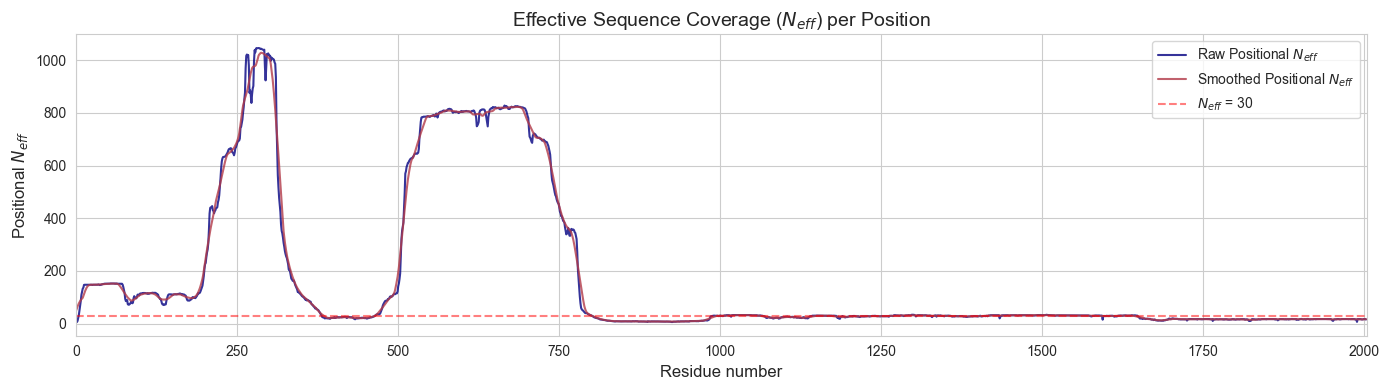

In [ ]:
# @title Calculate and Plot Neff Per Position

is_residue = (msa_use != "-")
per_pos_neff = weights @ is_residue.astype(np.float64)  # shape (L,)

#retrieve pLDDT for query sequence (row 0)
plddt = np.array(plddt_scores)

#check that lengths match
assert len(per_pos_neff) == len(plddt), (
    f"Length mismatch: per_pos_neff={len(per_pos_neff)}, plddt={len(plddt)}"
)

def nan_aware_smooth(y, window=15):
    """
    Box-kernel smoothing that ignores NaN positions.
    NaN positions contribute neither signal nor weight to
    their neighbours, so low-coverage or masked columns
    do not distort the profile around them.
    """
    y = np.asarray(y, dtype=float)
    y_filled = np.where(np.isfinite(y), y, 0.0)
    valid    = np.isfinite(y).astype(float)
    kernel   = np.ones(window) / window

    smoothed_num   = np.convolve(y_filled, kernel, mode='same')
    smoothed_denom = np.convolve(valid,    kernel, mode='same')

    with np.errstate(invalid='ignore'):
        result = np.where(smoothed_denom > 0,
                          smoothed_num / smoothed_denom,
                          np.nan)
    return result


# Smoothing the data for visualisation
window_size = 20
smoothed_neff = nan_aware_smooth(per_pos_neff, window=window_size)

# 3. Plot the result
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(per_pos_neff, alpha=0.8, color="#020081", label='Raw Positional $N_{eff}$')
ax.plot(smoothed_neff, alpha=0.8, color="#B23A48", label='Smoothed Positional $N_{eff}$')

# Add a horizontal line (e.g., Neff = 30)
ax.axhline(30, color='red', linestyle='--', alpha=0.5, label='$N_{eff}$ = 30')

ax.set_xlim(0, L)
ax.set_xlabel('Residue number', fontsize=12)
ax.set_ylabel('Positional $N_{eff}$', fontsize=12)
ax.set_title('Effective Sequence Coverage ($N_{eff}$) per Position', fontsize=14)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

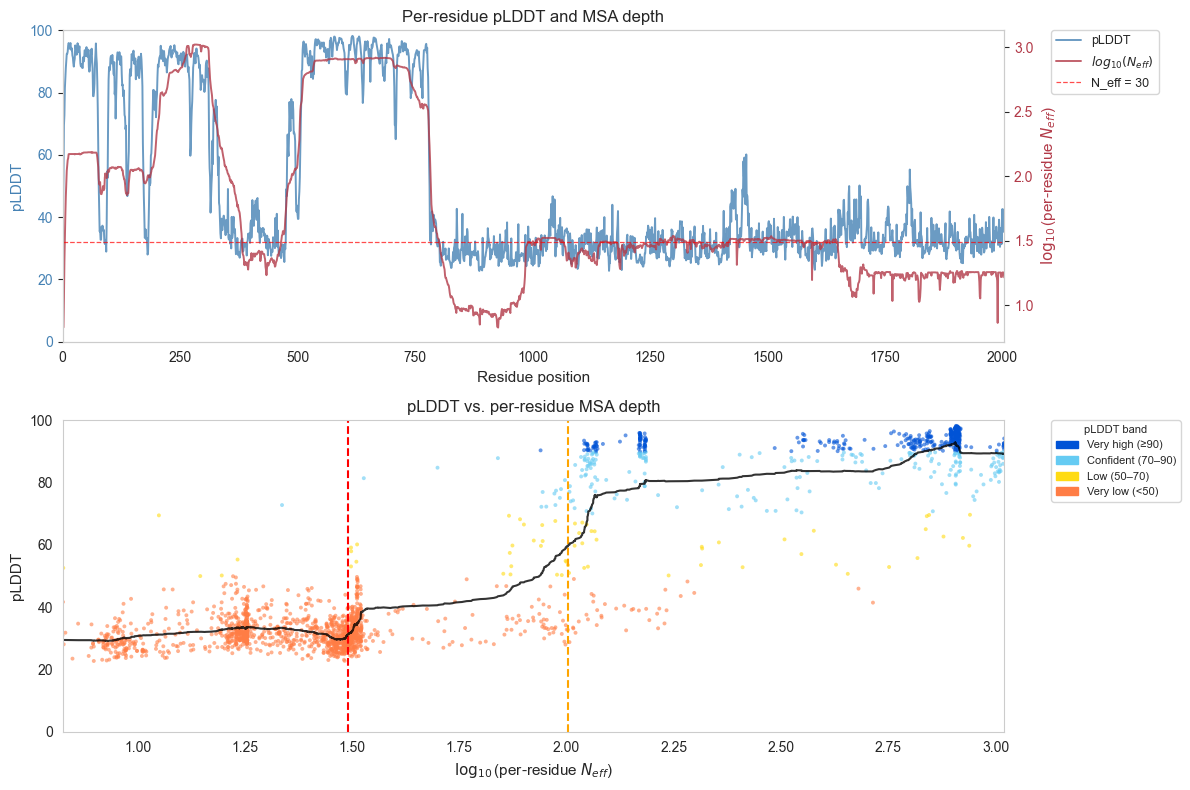

In [ ]:
#@markdown Plot $N_{eff}$ with pLDDT and MSA depth agains pLDDT
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

residue_idx = np.arange(1, len(plddt) + 1)
ax1 = axes[0]
ax2 =ax1.twinx()

ax1.plot(residue_idx, plddt, color='steelblue', lw=1.4, alpha=0.8, label='pLDDT')
ax1.set_xlabel('Residue position', fontsize=11)
ax1.set_ylabel('pLDDT', color='steelblue', fontsize=11)
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_ylim(0, 100)

ax2.plot(residue_idx, np.log10(per_pos_neff + 1), color="#B23A48",
         lw=1.4, alpha=0.8, label=r'$log_{10}(N_{eff})$')
ax2.axhline(np.log10(31),  color='red',   lw=0.9, ls='--', alpha=0.7,
            label='N_eff = 30')

ax2.set_ylabel(r"$\log_{10}$(per-residue $N_{eff}$)", color="#B23A48", fontsize=11)
ax2.tick_params(axis='y', labelcolor="#B23A48")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9,
           loc='upper left',                # anchor point inside legend box
          bbox_to_anchor=(1.05, 1),        # position outside axes (right side)
          borderaxespad=0)
ax1.set_title('Per-residue pLDDT and MSA depth', fontsize=12)
ax1.grid(False)
ax2.grid(False)
ax2.set_xlim(0, len(plddt))

# --- Second plot: scatter pLDDT vs log10(per-residue N_eff) ------------
ax = axes[1]

# Colour points by pLDDT band (AF2 convention)
colors = np.where(plddt >= 90, '#0053D6',        # very high
         np.where(plddt >= 70, '#65CBF3',         # confident
         np.where(plddt >= 50, '#FFDB13',         # low
                               '#FF7D45')))        # very low

sc = ax.scatter(np.log10(per_pos_neff + 1), plddt,
                c=colors, alpha=0.6, s=8, linewidths=0)

# AlphaFold thresholds
ax.axvline(np.log10(31),  color='red',    lw=1.5, ls='--',
           label=r'$N_{eff}$ = 30')
ax.axvline(np.log10(101), color='orange', lw=1.5, ls='--',
           label=r'$N_{eff}$ = 100')

# Smoothed trend line
from scipy.ndimage import uniform_filter1d
sort_idx   = np.argsort(per_pos_neff)
x_sorted   = np.log10(per_pos_neff[sort_idx] + 1)
y_sorted   = plddt[sort_idx]
y_smoothed = uniform_filter1d(y_sorted.astype(float), size=max(1, len(y_sorted)//10)) # smooth over 10% of the length
ax.plot(x_sorted, y_smoothed, color='black', lw=1.5, alpha=0.8,
        label='Smoothed trend')

ax.set_xlabel(r"$\log_{10}$(per-residue $N_{eff}$)", fontsize=11)
ax.set_ylabel('pLDDT', fontsize=11)
ax.set_ylim(0, 100)
ax.set_title('pLDDT vs. per-residue MSA depth', fontsize=12)
ax.legend(fontsize=9,
          loc='upper left')
ax.set_xlim(np.log10(per_pos_neff.min() + 1), np.log10(per_pos_neff.max() + 1))
ax.grid(False)

# pLDDT band legend (manual)
from matplotlib.patches import Patch
band_legend = [
    Patch(color='#0053D6', label='Very high (≥90)'),
    Patch(color='#65CBF3', label='Confident (70–90)'),
    Patch(color='#FFDB13', label='Low (50–70)'),
    Patch(color='#FF7D45', label='Very low (<50)'),
]
ax.legend(handles=band_legend,
          fontsize=8,
          loc='upper left',                # anchor point inside legend box
          bbox_to_anchor=(1.05, 1),        # position outside axes (right side)
          borderaxespad=0,
          title='pLDDT band',
          title_fontsize=8)

plt.tight_layout()
plt.show()

#### Top panel

Read this as a **co-registration of evolutionary support and structural confidence** along the sequence. The red line shows the $\log_{10}$ of per-residue $N_{eff}$. Whereas the blue line shows the per-residue pLDDT.

#### Bottom panel

This panel shows the same data as the previous plot but as a distribution rather than a sequence profile, making the overall relationship between MSA depth and confidence easier to assess. The trend line summarises the average pLDDT at each depth level.

The dashed line marks $N_{eff}$​ = 30 and $N_{eff}$ = 100, as references that appear repeatedly in the co-evolution and structure prediction papers as an informal lower bound below which prediction accuracy tends to decline for proteins without PDB templates. It is drawn here purely as a visual reference point to help locate regions relative to that discussion, **not as a hard threshold**. Whether a given region is adequately supported depends on the protein, its domain architecture, and whether structural templates are available. Check out the papers I mentioned before the in the Neff section above.

#### What not to conclude

- A high per-residue $N_{eff}$ does not mean a region is correctly predicted. It means it is well-supported by evolutionary data. Always cross-check with the PAE plot for domain-level confidence.
- A low pLDDT does not always mean the region is unstructured, it may adopt a stable conformation only in the context of a binding partner or post-translational modification not captured in the MSA.
- These plots describe the **evidence available to AlphaFold**, not the ground truth of the protein's behaviour.

## <font color='#077187' size=16> **Analysis 2: Measuring per-residue conservation** </font>

Having established the global diversity of the MSA, we now move to a position-by-position analysis. Conservation at each column of the alignment is quantified using two complementary metrics: Shannon entropy, which measures how variable a position is across the alignment, and KL divergence, which measures how unusual the composition of that position is relative to typical protein sequences. Used together, they provide a more complete picture than either metric alone.

* <font color='#f7c59f'> A: Shannon Entropy </font>

[Shannon entropy ($H$)](https://people.math.harvard.edu/~ctm/home/text/others/shannon/entropy/entropy.pdf) is an information-theoretic measure of uncertainty. In the context of an MSA, it quantifies how variable a given column is, a column where every sequence has the same amino acid carries no uncertainty and has entropy of zero; a column where all 20 amino acids appear equally often is maximally uncertain and has entropy of $\log_2(20) \approx 4.32$ bits. Applied column by column across the alignment, it gives a per-residue profile of evolutionary variability.

For column $i$ of the MSA, Shannon entropy is defined as:

$$H_i = -\sum_{a=1}^{20} P(a_i) \log_2 P(a_i)$$

Where:
- $P(aa_i)$ is the frequency (probability) of a specific amino acid appearing in column $i$.
- The sum runs over the 20 standard amino acids (and optionally the gap character).

How to interpret it?
* Low entropy (near 0): one residue dominates among non-gap sequences → often reflects structural or functional constraint.
* High entropy: multiple residues tolerated → often surface, flexible regions, or specificity loops (which can still be biologically important).
* Max entropy: log_2(20)≈ 4.32 when amino acids are equally frequent.

A low entropy score identifies positions that evolution has been unable or unwilling to change — strong evidence of structural or functional importance. However, conservation is necessary but not sufficient for functional annotation: a deeply buried hydrophobic residue critical for core packing will also score near zero, regardless of whether it is catalytically relevant. Structural context is always required to distinguish these cases.
<br>
<br>

#### Gap handling

- If a columns is 50% alanine and 50% gaps, is it conserved? You can treat the gap as a 21st amino acid. But this inflates entropy and treats a deletion as a "mutation", which if often chemically incorrect for structural stability analysis. One alternative is to ignore gaps for the entropy calculation but flag the column if the gap fraction exceeds a threshold (e.g. > 50%). However, if you ignore gaps, you must re-normalise the frequencies of the remaining amino acids so they sum to 1.

- If an alignment only has 5 sequences, a "perfectly conserved" column is statistically insignificant. For now, we'll assume that we have enough sequences from the MSAs. But if not, you can implement a small sample correction.

How gaps are treated materially affects entropy estimates, and the choice should be made explicitly:

- **Treating gaps as a 21st character** inflates entropy at insertion/deletion-rich positions and conflates a deletion event with an amino acid substitution — chemically and structurally these are very different. This is generally not
recommended for conservation analysis.

- **Ignoring gaps and renormalising** (the approach used here) computes entropy only over sequences that have a residue at that position, then renormalises the remaining frequencies to sum to 1. This gives an accurate picture of amino acid
variability among sequences that actually encode that region. However, it can be misleading when the gap fraction is high — an apparently "conserved" position based on five non-gap sequences out of 500 total is not meaningfully conserved. For this reason, gap fraction is tracked separately and reported alongside entropy, and positions with gap fraction above 50% are flagged as low-coverage.

<br>

## <font color='#f7c59f'> Kullback-Leibler Divergence (Relative entropy) </font>

Shannon entropy treats all amino acids as equally likely background characters: a column that is 100% Leucine and a column that is 100% Tryptophan would both receive an entropy score of zero, because both are perfectly conserved. But these two cases are not equivalent from an evolutionary standpoint.

Leucine is the most abundant amino acid in the UniProtKB database (~ 9.7% background frequency), while Tryptophan is the rarest (~1.1%). A fully conserved Tryptophan represents a far stronger evolutionary constraint — it has been maintained against a strong background pressure toward substitution. Shannon entropy is blind to this distinction.

[Kullback-Leibler (KL) divergence](https://www.jstor.org/stable/2236703?read-now=1), also called relative entropy, addresses this by comparing the observed column distribution $P$ to a background distribution $Q$ of amino acid frequencies derived from a large reference
proteome (here, UniProtKB statistics):


$$D_{\text{KL}}(P \| Q) = \sum_{a=1}^{20} P(a_i) \log_2 \frac{P(a_i)}{Q(a)}$$


A high $D_{\text{KL}}$ at a position means its amino acid composition is
significantly enriched for residues that are rare in proteins generally — a signal
of strong, specific evolutionary selection. A low $D_{\text{KL}}$ means the
composition looks broadly like background, even if the position has low entropy.


#### A practical note on pseudocounts

KL divergence is undefined when $P(a_i) = 0$ for any amino acid $a$ (because
$\log_2(0/Q)$ diverges). In practice, a small pseudocount is added to each
observed frequency before computing the divergence, effectively assuming each
amino acid has been observed at least once. This prevents infinite values while
having negligible effect when real counts are large.


**Note**: This script uses a simple flat pseudocount to handle zero-frequencies. Advanced sequence analysis tools (like PSI-BLAST or HH-suite) use background-dependent pseudocounts derived from BLOSUM matrices to incorporate biophysical substitution probabilities when alignments are shallow

---

### Why use both metrics together?

Shannon entropy and KL divergence are complementary. Entropy captures *how conserved* a position is; KL divergence captures *how surprising* that conservation is given background amino acid frequencies. A position that scores low on entropy
and high on KL divergence is the most informative: it is both highly conserved and enriched for a chemically specific residue that has been maintained against the statistical odds. The scatter plot in the analysis below visualises both dimensions simultaneously, allowing candidate functional residues to be identified and prioritised.

---

### **References**

#### The mathematical foundations

These papers introduced the fundamental concepts of information theory used across machine learning and bioinformatics today.
* **Shannon, C.E. (1948)** *A mathematical theory of communication.* Bell System Technical Journal, 27(3), 379–423.
  > The foundational text of information theory. Shannon originally derived "entropy" to quantify the uncertainty of signals sent over noisy telegraph wires; bioinformatics later adapted this exact formula to quantify the evolutionary "uncertainty" of amino acid mutations in a protein column.
* **Kullback, S. & Leibler, R.A. (1951)** *On information and sufficiency.* Annals of Mathematical Statistics, 22(1), 79–86.
  > The mathematical origin of "relative entropy" (KL Divergence). This paper established the framework for measuring how much one probability distribution diverges from an expected background distribution.


These papers demonstrate how to take the raw math of information theory and apply it to biological sequences to find functional constraints.
* **Strait, B.J. & Dewey, T.G. (1996)** *The Shannon information entropy of protein sequences.* Biophysical Journal, 71(1), 148-155.
  > An early study that treats protein sequences like a "language." The authors calculate the baseline Shannon entropy of natural proteins (roughly 2.5 bits per amino acid) and compare it to the theoretical maximum, showing how physical constraints inherently limit amino acid randomness.
* **Valdar, W.S.J. (2002)** *Scoring residue conservation.* Proteins, 48(2), 227–241.
  > It systematically breaks down the biological assumptions behind different conservation metrics, offering deep insights into sequence weighting, gap handling, and why simply counting mutations is biologically insufficient.
* **Capra, J.A. & Singh, M. (2007)** *Predicting functionally important residues from sequence conservation.* Bioinformatics, 23(15), 1875–1882.
  > The authors evaluate several scoring methods to see which mathematically identifies actual 3D catalytic active sites and ligand-binding pockets most accurately.

These recent papers highlight how entropy and KL divergence are currently being used in advanced genomics, cancer research, and computational protein design.
* **Sen, S. et al. (2019)** *Understanding the evolutionary trend of intrinsically structural disorders in cancer relevant proteins as probed by Shannon entropy scoring and structure network analysis.* BMC Bioinformatics, 19(Suppl 13):549.
  > The authors use Shannon entropy scoring directly on protein sequences to track the evolutionary trends of Intrinsically Disordered Regions (IDRs) in cancer-related proteins, linking sequence uncertainty to structural flexibility and disease.
* **Akhter, S. et al. (2017)** *Kullback Leibler divergence in complete bacterial and phage genomes.* PeerJ, 5:e4026.
  > While this notebook applies KL divergence to single MSA columns, this paper scales the concept up to entire genomes. It shows how KL divergence can be used to compare the overall amino acid compositions of different organisms.


In [ ]:
#@markdown  calculate shannon entropy and KL divergence
AA20 = "ACDEFGHIKLMNPQRSTVWY"
AA_SET = set(AA20)
# non-standard amino acids are simply ignored.

# Background residue frequencies from UniProtKB statistics
#taken from: https://www.uniprot.org/uniprotkb/statistics#amino-acid-composition
UNIPROT_BG = {
    'L': 0.0977, 'A': 0.0871, 'S': 0.0718, 'G': 0.0708, 'V': 0.0675,
    'E': 0.0628, 'R': 0.0582, 'T': 0.0560, 'D': 0.0544, 'I': 0.0533,
    'P': 0.0515, 'K': 0.0504, 'Q': 0.0392, 'N': 0.0387, 'F': 0.0384,
    'Y': 0.0285, 'M': 0.0232, 'H': 0.0230, 'C': 0.0141, 'W': 0.0130
}

def calculate_entropy(
    msa_chars,
    weights=None,
    gap_char='-',
    pseudocount=1e-3,
    min_nongap=2.0
):
    """
    Compute per-column Shannon entropy (H) and KL divergence (D_KL)
    across a weighted MSA.
    Parameters
    ----------
    msa_chars : (N, L) array of single characters
        Aligned sequences. Must match the array used to compute weights.
    weights : (N,) array, optional
        Per-sequence weights from N_eff calculation. If None, all
        sequences are weighted equally (unweighted MSA).
    gap_char : str
        Gap character to exclude from frequency calculations.
    pseudocount : float
        Small value added to amino acid frequencies before computing
        KL divergence, to prevent log(0). Not applied to Shannon entropy.
    min_nongap : float
        Minimum effective non-gap weight for a column to be scored.
        Columns below this threshold are returned as NaN to discourage
        overinterpretation of poorly covered positions.

    Returns

    H           : (L,) Shannon entropy in bits. NaN for low-coverage columns.
    KL          : (L,) KL divergence vs UniProtKB background in bits.
    cons01      : (L,) Conservation score in [0, 1]; 1 - H / log2(20).
    gap_frac    : (L,) Weighted gap fraction per column.
    nongap_eff  : (L,) Effective non-gap weight per column (sum of
                  weights of non-gap sequences).
    """

    msa = np.asarray(msa_chars)
    if msa.ndim != 2:
        raise ValueError("msa_chars must be a (N,L) array of single characters.")

    N, L = msa.shape

    if weights is None:
        w = np.ones(N, dtype=float)
    else:
        w = np.asarray(weights, dtype=float)
        if w.shape[0] != N:
            raise ValueError(
                f"weights has length {w.shape[0]} but MSA has {N} sequences."
                f"weights must have length N (number of sequences).")

    w_total = w.sum()

    bg = np.array([UNIPROT_BG[a] for a in AA20], dtype=float)
    bg = bg / bg.sum() # ensure background frequencies sum to 1
    max_H = np.log2(20) # maximum entropy for 20 amino acids

    H = np.full(L, np.nan, dtype=float)
    KL = np.full(L, np.nan, dtype=float)
    gap_frac = np.full(L, np.nan, dtype=float)
    nongap_eff = np.full(L, np.nan, dtype=float)

    for i in range(L):
        col = msa[:, i]
        is_gap = (col == gap_char)
        is_aa = np.isin(col, list(AA20))
        mask = is_aa & ~is_gap  # valid amino acid residues (exclude gaps and unknowns)

        # weighted gap fraction
        gap_frac[i] = float(np.sum(w[is_gap])) / w_total

        if not np.any(mask):
            nongap_eff[i] = 0.0
            continue

        w_col = w[mask]
        nongap_eff[i] = float(w_col.sum()) # sum of weights for non-gap sequences in this column

        if nongap_eff[i] < min_nongap:
            # too few non-gap sequences: keep NaN to discourage overinterpretation
            continue

        counts = np.zeros(20, dtype=float) # counts for AA20
        for j, aa in enumerate(AA20):
            counts[j] = np.sum(w_col[col[mask] == aa])

        # convert counts to frequencies
        total = counts.sum()
        if total <= 0:
            continue

        p_raw = counts / total # unnormalized frequencies

        # shannon entropy = use raw frequencies without pseudocounts
        nonzero = p_raw > 0
        H[i] = -np.sum(p_raw[nonzero] * np.log2(p_raw[nonzero])) # only sum over non-zero frequencies

        # KL divergence = apply pseudocounts to avoid log(0)
        p_smooth = p_raw + pseudocount
        p_smooth = p_smooth / p_smooth.sum() # renormalize after adding pseudocounts
        KL[i] = np.sum(p_smooth * np.log2(p_smooth / bg))

    conservation_01 = np.clip(1.0 - (H/max_H), 0.0, 1.0)
    return H, KL, conservation_01, gap_frac, nongap_eff

H, KL, cons01, gap_frac, nongap_eff = calculate_entropy(msa_use, weights=weights)

print(f"Computed H and KL for {np.sum(np.isfinite(H))} of {len(H)} positions.")
print(f"Positions skipped (low coverage or all gaps): "f"{np.sum(~np.isfinite(H))}")
print(f"Shannon entropy (H) range: {np.nanmin(H):.2f} to {np.nanmax(H):.2f} bits")
print(f"KL divergence (D_KL) range: {np.nanmin(KL):.2f} to {np.nanmax(KL):.2f} bits")

Computed H and KL for 2004 of 2004 positions.
Positions skipped (low coverage or all gaps): 0
Shannon entropy (H) range: -0.00 to 4.08 bits
KL divergence (D_KL) range: 0.10 to 5.83 bits


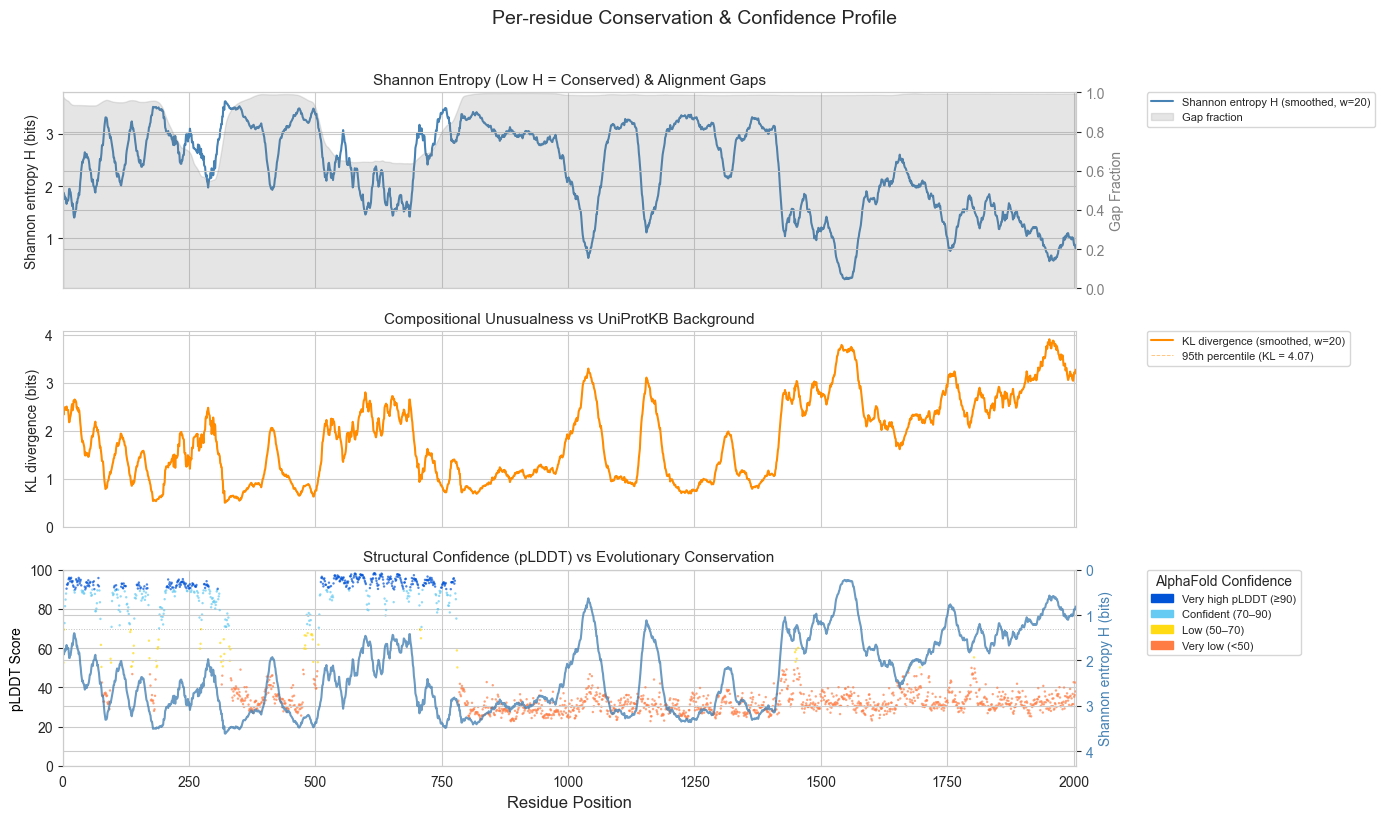

In [ ]:
#@markdown This cell will plot the Shannon entropy and the KL diverge

def plot_conservation_profile(
    H, KL, cons01, gap_frac, nongap_eff, plddt,
    sequence,
    window=15,
    min_nongap=2.0,
    figsize=(14, 8) # Reduced height since we removed a panel
):
    """
    Three-panel conservation summary figure.

    Panel 1: Smoothed Shannon entropy with gap fraction overlay on a secondary axis.
    Panel 2: Smoothed KL divergence (compositional unusualness).
    Panel 3: pLDDT coloured by AF2 confidence bands + smoothed conservation.
    """
    L   = len(sequence)
    x   = np.arange(1, L + 1)

    # Mask low-coverage positions before smoothing
    H_masked    = np.where(nongap_eff >= min_nongap, H,    np.nan)
    KL_masked   = np.where(nongap_eff >= min_nongap, KL,   np.nan)
    cons_masked = np.where(nongap_eff >= min_nongap, cons01, np.nan)

    # NaN-aware smoothed profiles
    H_smooth    = nan_aware_smooth(H_masked,    window=window)
    kl_smooth   = nan_aware_smooth(KL_masked,   window=window)
    cons_smooth = nan_aware_smooth(cons_masked, window=window)
    gap_smooth  = nan_aware_smooth(gap_frac,    window=window)

    # Changed to 3 subplots
    fig, axes = plt.subplots(3, 1, figsize=figsize, sharex=True,
                             gridspec_kw={'height_ratios': [2, 2, 2]})
    fig.suptitle('Per-residue Conservation & Confidence Profile', fontsize=14, y=1.02)

    # ── Panel 1: Shannon entropy + gap fraction (FIXED SCALING) ───
    ax1 = axes[0]
    ax1_gap = ax1.twinx() # Create a secondary y-axis for gap fraction

    # Plot Entropy on primary axis
    ax1.plot(x, H_smooth, color='steelblue', lw=1.5,
            label=f'Shannon entropy H (smoothed, w={window})')


    # Plot Gap Fraction on secondary axis
    ax1_gap.fill_between(x, 0, gap_smooth, alpha=0.2, color='grey',
                    label='Gap fraction')
    ax1_gap.set_ylim(0, 1) # Force gap fraction to 0-1 scale
    ax1_gap.set_ylabel('Gap Fraction', color='grey')
    ax1_gap.tick_params(axis='y', labelcolor='grey')

    ax1.set_ylabel('Shannon entropy H (bits)')

    # Combine legends from both axes
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax1_gap.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, fontsize=8,
              loc='upper left', bbox_to_anchor=(1.07, 1), borderaxespad=0)

    ax1.set_title('Shannon Entropy (Low H = Conserved) & Alignment Gaps', fontsize=11)
    ax1.set_xlim(0, L)

    # ── Panel 2: KL divergence ────────────────────────────────────
    ax2 = axes[1]
    ax2.plot(x, kl_smooth, color='darkorange', lw=1.5,
            label=f'KL divergence (smoothed, w={window})')

    kl_thresh = np.nanpercentile(KL_masked, 95)
    ax2.axhline(kl_thresh, color='darkorange', lw=0.7, ls='--', alpha=0.5,
               label=f'95th percentile (KL = {kl_thresh:.2f})')

    ax2.set_ylim(bottom=0)
    ax2.set_ylabel('KL divergence (bits)')
    ax2.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.07, 1), borderaxespad=0)
    ax2.set_title('Compositional Unusualness vs UniProtKB Background', fontsize=11)

    # ── Panel 3: pLDDT + conservation overlay ────────────────────
    ax3  = axes[2]
    ax3_cons = ax3.twinx()

    # pLDDT coloured by AF2 confidence bands
    plddt_arr = np.asarray(plddt, float)
    colors_band = np.where(plddt_arr >= 90, '#0053D6',
                  np.where(plddt_arr >= 70, '#65CBF3',
                  np.where(plddt_arr >= 50, '#FFDB13', '#FF7D45')))

    ax3.scatter(x, plddt_arr, c=colors_band, s=3, alpha=0.7, linewidths=0)
    ax3.set_ylim(0, 100)
    ax3.set_ylabel('pLDDT Score', color='black')
    ax3.axhline(70, color='grey', lw=0.7, ls=':', alpha=0.5)

    # Conservation on right axis
    ax3_cons.plot(x, H_smooth, color='steelblue', lw=1.5, alpha=0.8,
             label='')
    ax3_cons.set_ylim(np.log2(20), 0)
    ax3_cons.set_ylabel('Shannon entropy H (bits)', color='steelblue')
    ax3_cons.tick_params(axis='y', labelcolor='steelblue')

    # pLDDT band legend
    band_legend = [
        Patch(color='#0053D6', label='Very high pLDDT (≥90)'),
        Patch(color='#65CBF3', label='Confident (70–90)'),
        Patch(color='#FFDB13', label='Low (50–70)'),
        Patch(color='#FF7D45', label='Very low (<50)'),
    ]
    ax3.legend(handles=band_legend, fontsize=8, loc='upper left',
               bbox_to_anchor=(1.07, 1), borderaxespad=0, title='AlphaFold Confidence')

    ax3.set_title('Structural confidence (pLDDT) vs Shannon entropy', fontsize=11)
    ax3.set_xlabel('Residue position', fontsize=12)

    plt.tight_layout()
    plt.show()

# ── Run ───────────────────────────────────────────────────────────
plot_conservation_profile(
    H, KL, cons01, gap_frac, nongap_eff,
    plddt   = plddt_scores,
    sequence = query_seq,
    window   = 20,
    min_nongap = 2.0
)

### How to interpret the conservation profile

This three-panel plot synthesizes the evolutionary data (MSA) with AlphaFold's structural prediction confidence (pLDDT). Here is how the metrics are calculated and what they mean:

#### 1. The gap fraction warning (Panel 1)
Shannon entropy mathematically ignores gaps. If a column in the MSA consists of 499 gaps and 1 Alanine, the entropy formula evaluates the available data as "100% Alanine" and assigns it a score of 0 (perfect conservation).

To prevent misinterpreting a lack of data as evolutionary constraint, the **Gap Fraction** (the grey area) is plotted on a secondary axis from 0.0 to 1.0.
- If the blue entropy line drops to 0, but the grey gap fraction spikes near 1.0, that residue is not strictly conserved—it is merely unique to your specific query sequence (or a very narrow taxonomic clade) and lacks sufficient alignment depth.

#### 2. KL divergence, compositional unusualness (Panel 2)

KL divergence measures how far the observed amino acid distribution at each position deviates from what you would expect by chance in a typical protein. A high KL score means the position is enriched for residues that are rare in the proteome generally, a signal of specific, non-trivial selection.

The dashed line marks the 95th percentile of KL values across the protein.
Positions above it are in the top 5% of compositionally unusual sites, a useful first filter when looking for functionally important residues alongside the conservation data in Panel 1.

#### 3. The normalised conservation score (Panel 3)

Panel 3 overlays Shannon entropy H directly on the right axis, inverted so that the top of the axis corresponds to low H (conserved) and the bottom to high H (variable). This keeps the visual direction consistent with pLDDT — both lines peak upward for well-supported, confidently predicted regions.

➔ Starting with 2004 total residues in the sequence.
Residues remaining after dropping NaNs: 2004
Residues remaining after max_gap (≤ 0.8): 336
Residues remaining after min_nongap_eff (≥ 2.0): 336
KL threshold (q=0.95): 4.980
Entropy threshold (q=0.10, low tail): 0.496


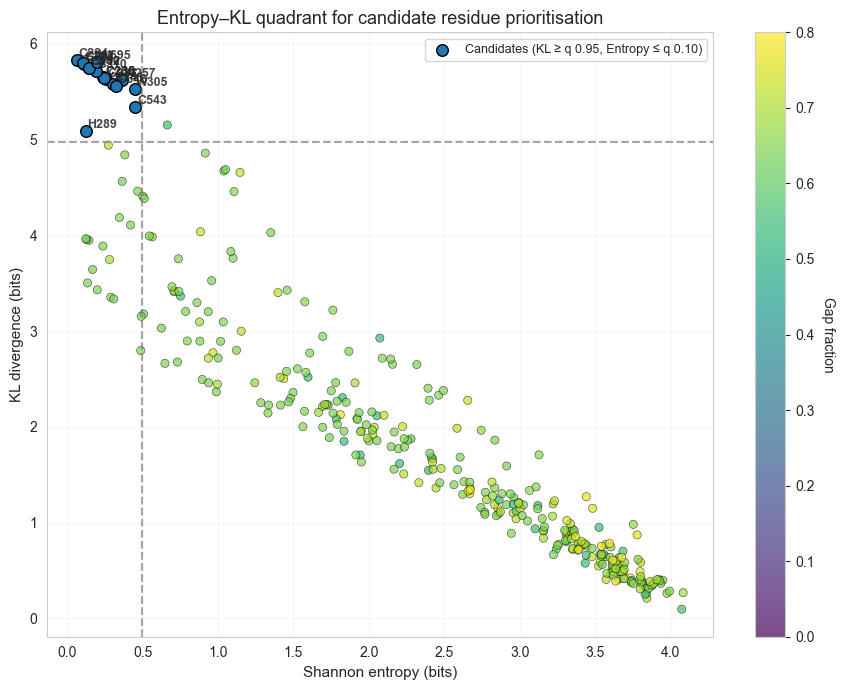

,Residue,Position,Entropy,KL,GapFrac,NonGapEff
0,C,284,0.067488,5.834003,0.539174,1046.841869
1,W,695,0.199246,5.807206,0.638872,820.334489
2,C,307,0.107295,5.799104,0.557532,1005.141004
3,C,281,0.112778,5.790753,0.539213,1046.754480
4,C,292,0.142600,5.748485,0.542696,1038.844635
5,C,540,0.146060,5.747876,0.654147,785.663731
6,C,310,0.190045,5.714766,0.565474,987.099580
7,C,230,0.240727,5.650348,0.721345,633.012445
8,C,265,0.246624,5.645396,0.552204,1017.244809
9,C,233,0.255453,5.629420,0.719661,636.837436


In [ ]:
#@markdown Here you will get a plot for residues that fall within the functional/structural quadrant due to high KL divergence and low Shannon entropy (i.e. conserved positions)

def plot_entropy_kl_quadrant(
    H, KL, sequence, gap_frac, nongap_eff,
    max_gap=0.8,
    min_nongap_eff=2.0,
    kl_quantile=0.95,
    entropy_quantile=0.10,   # low entropy = more conserved
    annotate=True
):
    H = np.asarray(H, float)
    KL = np.asarray(KL, float)
    gap_frac = np.asarray(gap_frac, float)
    nongap_eff = np.asarray(nongap_eff, float)

    df = pd.DataFrame({
        "Residue": list(sequence),
        "Position": np.arange(1, len(sequence) + 1),
        "Entropy": H,
        "KL": KL,
        "GapFrac": gap_frac,
        "NonGapEff": nongap_eff
    })

    print(f"➔ Starting with {len(df)} total residues in the sequence.")

    # Drop invalid values
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["Entropy", "KL"])
    print(f"Residues remaining after dropping NaNs: {len(df)}")

    # Filter by gap fraction
    df = df[df["GapFrac"] <= max_gap]
    print(f"Residues remaining after max_gap (≤ {max_gap}): {len(df)}")

    # Filter by non-gap effective sequences
    df = df[df["NonGapEff"] >= min_nongap_eff]
    print(f"Residues remaining after min_nongap_eff (≥ {min_nongap_eff}): {len(df)}")

    if df.empty:
        print("No residues left after filtering. Try relaxing max_gap or min_nongap_eff.")
        return pd.DataFrame()

    # Dynamic thresholds from surviving residues
    kl_thr = df["KL"].quantile(kl_quantile)
    ent_thr = df["Entropy"].quantile(entropy_quantile)  # lower tail = more conserved

    print(f"KL threshold (q={kl_quantile:.2f}): {kl_thr:.3f}")
    print(f"Entropy threshold (q={entropy_quantile:.2f}, low tail): {ent_thr:.3f}")

    # Candidates = high KL + low entropy
    candidates = df[(df["KL"] >= kl_thr) & (df["Entropy"] <= ent_thr)].copy()

    # ── Plotting ───────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(9, 7))

    # All valid residues (colored by gap fraction)
    sc = ax.scatter(
        df["Entropy"], df["KL"],
        c=df["GapFrac"], cmap="viridis",
        vmin=0, vmax=max_gap,
        alpha=0.7, s=35, linewidths=0.4, edgecolors="black"
    )

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("Gap fraction", rotation=270, labelpad=15)

    # Highlight candidates
    if not candidates.empty:
        ax.scatter(
            candidates["Entropy"], candidates["KL"],
            s=70, linewidths=1.0, edgecolors="black",
            label=(
                f"Candidates (KL ≥ q {kl_quantile:.2f}, "
                f"Entropy ≤ q {entropy_quantile:.2f})"
            )
        )

        if annotate:
            for _, row in candidates.iterrows():
                ax.text(
                    row["Entropy"] + 0.01, row["KL"] + 0.03,
                    f"{row['Residue']}{int(row['Position'])}",
                    fontsize=9, fontweight="bold", alpha=0.85
                )

    # Threshold lines (top-left quadrant is interesting)
    ax.axhline(kl_thr, color="grey", linestyle="--", alpha=0.7)
    ax.axvline(ent_thr, color="grey", linestyle="--", alpha=0.7)

    # Labels and title
    ax.set_xlabel("Shannon entropy (bits)", fontsize=11)
    ax.set_ylabel("KL divergence (bits)", fontsize=11)
    ax.set_title("Entropy–KL quadrant for candidate residue prioritisation", fontsize=13)

    if not candidates.empty:
        ax.legend(loc="upper right", fontsize=9)

    ax.grid(True, alpha=0.15)
    plt.tight_layout()
    plt.show()

    # Sort useful output table
    candidates = candidates.sort_values(
        by=["KL", "Entropy", "NonGapEff"],
        ascending=[False, True, False]
    ).reset_index(drop=True)

    return candidates

candidates_df = plot_entropy_kl_quadrant(H, KL, query_seq, gap_frac, nongap_eff)
candidates_df.head(20)

This plot highlights residues with high KL divergence and low Shannon entropy (i.e. conserved positions), after filtering for alignment support (gap fraction and non-gap effective sequences). These are prioritised candidates for follow-up, not definitive functional residues.

In [ ]:
#@markdown Get a table of prioritised residues from the Entropy–KL candidate quadrant (high KL, low Shannon entropy), after alignment support filtering.
def list_entropy_kl_candidates(
    H, KL, sequence,
    gap_frac=None,
    nongap=None,
    top_percent=2.0,          # number of rows to show (relative to sequence length)
    max_gap=0.8,
    min_nongap=2.0,
    kl_quantile=0.95,         # keep high-KL residues
    entropy_quantile=0.10,    # keep low-entropy residues (more conserved)
    rank_by="KL",             # "KL", "Entropy", "KL_then_Entropy"
    return_filtered=False
):
    """
    Returns and displays a table of residues with high KL divergence and low Shannon entropy,
    after optional gap/support filtering.

    Notes
    -----
    - Low entropy = more conserved
    - High KL = more compositionally unusual/specific vs background
    - This is a prioritisation heuristic, not proof of function
    """
    L = len(sequence)
    H = np.asarray(H, float)
    KL = np.asarray(KL, float)

    if len(H) != L or len(KL) != L:
        raise ValueError("H, KL, and sequence must have the same length.")

    df = pd.DataFrame({
        "Res": list(sequence),
        "Pos": np.arange(1, L + 1),
        "ResID": [f"{aa}{i}" for i, aa in enumerate(sequence, start=1)],
        "Entropy": H,
        "KL": KL,
    })

    if gap_frac is not None:
        gap_frac = np.asarray(gap_frac, float)
        if len(gap_frac) != L:
            raise ValueError("gap_frac must have the same length as sequence.")
        df["GapFrac"] = gap_frac

    if nongap is not None:
        nongap = np.asarray(nongap, float)
        if len(nongap) != L:
            raise ValueError("nongap must have the same length as sequence.")
        df["NonGapEff"] = nongap

    print(f"➔ Starting with {len(df)} total residues.")

    # Drop invalid values
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["Entropy", "KL"])
    print(f"Residues remaining after dropping NaNs: {len(df)}")

    # Support filters
    if "GapFrac" in df.columns:
        df = df[df["GapFrac"] <= max_gap]
        print(f"Residues remaining after max_gap (≤ {max_gap}): {len(df)}")

    if "NonGapEff" in df.columns:
        df = df[df["NonGapEff"] >= min_nongap]
        print(f"Residues remaining after min_nongap (≥ {min_nongap}): {len(df)}")

    if df.empty:
        print("⚠️ No residues passed support filters. Try relaxing max_gap or min_nongap.")
        return df

    # Dynamic thresholds based on surviving residues
    kl_thr = df["KL"].quantile(kl_quantile)
    ent_thr = df["Entropy"].quantile(entropy_quantile)  # lower tail = conserved

    print(f"KL threshold (q={kl_quantile:.2f}): {kl_thr:.3f}")
    print(f"Entropy threshold (q={entropy_quantile:.2f}, low tail): {ent_thr:.3f}")

    # Candidate filter: high KL + low entropy
    cand = df[(df["KL"] >= kl_thr) & (df["Entropy"] <= ent_thr)].copy()

    if cand.empty:
        print("⚠️ No candidates passed the KL + entropy thresholds. Try relaxing the quantiles.")
        return cand

    cand["EntropyRank"] = cand["Entropy"].rank(method="min", ascending=True).astype(int)
    cand["KLRank"] = cand["KL"].rank(method="min", ascending=False).astype(int)

    # Ranking
    if rank_by == "KL":
        cand = cand.sort_values(["KL", "Entropy"], ascending=[False, True])
        rank_label = "KL (descending), tie-break: Entropy (ascending)"
    elif rank_by == "Entropy":
        cand = cand.sort_values(["Entropy", "KL"], ascending=[True, False])
        rank_label = "Entropy (ascending), tie-break: KL (descending)"
    elif rank_by == "KL_then_Entropy":
        cand = cand.sort_values(["KL", "Entropy", "NonGapEff" if "NonGapEff" in cand.columns else "Pos"],
                                ascending=[False, True, False if "NonGapEff" in cand.columns else True])
        rank_label = "KL then Entropy (with support tie-break when available)"
    else:
        raise ValueError("rank_by must be one of: 'KL', 'Entropy', 'KL_then_Entropy'")

    # How many rows to display
    num_show = max(10, int(np.ceil(L * (top_percent / 100.0))))
    out = cand.head(num_show).copy()

    # Display columns
    cols = ["ResID", "KL", "Entropy"]
    if "GapFrac" in out.columns:
        cols.append("GapFrac")
    if "NonGapEff" in out.columns:
        cols.append("NonGapEff")
    cols += ["KLRank", "EntropyRank"]

    out_display = out[cols].round({
        "KL": 3,
        "Entropy": 3,
        "GapFrac": 3,
        "NonGapEff": 1
    })

    print(f"\nTop {top_percent}% residues (relative to sequence length) from the high-KL / low-entropy candidate set")
    print(f"Ranked by: {rank_label}")
    print("Heuristic only: validate with 3D structure, pLDDT/PAE, and biological context.\n")

    display(out_display)

    if return_filtered:
        return out, cand, df
    return out

candidates_df = list_entropy_kl_candidates(
    H=H,
    KL=KL,
    sequence=query_seq,
    gap_frac=gap_frac,
    nongap=nongap_eff,
    top_percent=2.0,
    max_gap=0.8,
    min_nongap=2.0,
    kl_quantile=0.95,
    entropy_quantile=0.10,
    rank_by="KL_then_Entropy"
)

➔ Starting with 2004 total residues.
Residues remaining after dropping NaNs: 2004
Residues remaining after max_gap (≤ 0.8): 336
Residues remaining after min_nongap (≥ 2.0): 336
KL threshold (q=0.95): 4.980
Entropy threshold (q=0.10, low tail): 0.496

Top 2.0% residues (relative to sequence length) from the high-KL / low-entropy candidate set
Ranked by: KL then Entropy (with support tie-break when available)
Heuristic only: validate with 3D structure, pLDDT/PAE, and biological context.



,ResID,KL,Entropy,GapFrac,NonGapEff,KLRank,EntropyRank
283,C284,5.834,0.067,0.539,1046.8,1,1
694,W695,5.807,0.199,0.639,820.3,2,8
306,C307,5.799,0.107,0.558,1005.1,3,2
280,C281,5.791,0.113,0.539,1046.8,4,3
291,C292,5.748,0.143,0.543,1038.8,5,5
539,C540,5.748,0.146,0.654,785.7,6,6
309,C310,5.715,0.190,0.565,987.1,7,7
229,C230,5.650,0.241,0.721,633.0,8,9
264,C265,5.645,0.247,0.552,1017.2,9,10
232,C233,5.629,0.255,0.720,636.8,10,11


## <font color='#077187' size=16>**Final notes**</font>

### What this notebook does and does not do

This notebook computes three things: how evolutionarily diverse the MSA is (Neff), how variable each position is across that alignment (Shannon entropy H), and how compositionally unusual each position is relative to background proteome frequencies (KL divergence). These are descriptions of the evolutionary evidence available to AlphaFold — they are not functional annotations.

A residue that scores well on both conservation and KL divergence is a strong *candidate* for functional importance. It is not a confirmed functional residue. Buried hydrophobic core residues, disulfide-forming cysteines, and glycine residues in tight turns all score similarly to catalytic residues by these metrics. Structural context — pocket membership, proximity to known ligands, PAE confidence across a domain interface — is always required to distinguish these cases.

### Suggested next steps

- **Cross-reference with UniProt**: the UniProt entry for your protein often contains curated active site, binding site, and post-translational modification annotations that can be directly compared against the candidates identified here.
- **Inspect in 3D**: load the AlphaFold structure in ChimeraX or PyMOL and colour by the conservation scores computed here. Candidates that are surface-exposed, lining a cavity, or at a domain interface are more likely to be functionally relevant than buried ones.
- **Check the PAE plot**: domain-level confidence from the PAE matrix complements the per-residue pLDDT. A region with high pLDDT but poor inter-domain PAE may be a well-folded domain whose orientation relative to the rest of the protein is uncertain.
- **Compare across homologs**: if orthologs are available, running this same notebook on a closely related protein and comparing the candidate lists can rapidly distinguish residues conserved across the entire family from those specific to your protein of interest.

### Limitations to keep in mind

- The MSA provided by AFDB is the one used during prediction. It was built with HHblits and Jackhmmer against UniRef90 and MGnify at the time of the database release. It may not reflect the most current sequence databases.
- For large multi-domain proteins, the MSA often has poor coverage in flexible linker regions and at termini. The gap fraction plot in Panel 1 of the conservation profile is the primary diagnostic for this.
- Neff is computed here on a subsample if the MSA is large. The conservation metrics (H and KL) are computed on the same subsample. Results are robust to subsampling for typical MSA sizes but may fluctuate slightly for very shallow alignments.